In [88]:
import matplotlib.pyplot as plt
import scipy.optimize as opt
import scipy.integrate
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution
import numpy as np
from scipy.optimize import least_squares
import pandas as pd

In [89]:
#para
rho_k = 0.002
gamma = 0.70
mu = 8.79/(1000* 52)
fixed_lam1 = 0.01

In [90]:
df = pd.read_csv("Cases.csv")
weekly_df = df[df["Cumulative"].notna()].copy()

observed_cumulative = weekly_df["Cumulative"].to_numpy() / 1_000_000
t_eval = np.arange(len(observed_cumulative))

In [91]:
#ODE System
def smirk_lambda1(t, y, beta_k, beta_m, phi, lam1, rho_k, gamma, mu):
    Sk, Ik, Rk, Sm, Im, Rm, C = y
    inf_force = beta_k * Ik + beta_m * Im
    mis_pool = Sm + Im + Rm
    mis_force = phi * mis_pool

    dSk = ((-rho_k*Sk) - (Sk * inf_force) - (mis_force * Sk) + (lam1 * Sm) + (mu * (Sk + Ik + Rk)) - mu * Sk)
    dIk = ( (Sk * inf_force) - (gamma * Ik) - (mis_force * Ik) + (lam1 * Im) - (mu * Ik))
    dRk = ((rho_k * Sk) + (gamma * Ik) - (mis_force * Rk) + (lam1 * Rm) - (mu * Rk))
    dSm = (-(Sm * inf_force) + (mis_force * Sk) - (lam1 * Sm) + (mu * (Sm + Im + Rm)) - (mu * Sm))
    dIm = ((Sm * inf_force) - (gamma * Im) + (mis_force * Ik) - (lam1 * Im) - (mu * Im))
    dRm = ((gamma * Im) + (mis_force * Rk) - (lam1 * Rm) - (mu * Rm))

    #Cumulative incidence
    dC = Sk * inf_force + Sm * inf_force

    return [dSk, dIk, dRk, dSm, dIm, dRm, dC]

In [92]:
#Simulate model
def simulate_fixed_lambda(params, t_eval, y0):
    beta_k, beta_m, phi = params

    sol = solve_ivp(
        smirk_lambda1,
        t_span=(t_eval[0], t_eval[-1]),
        y0=y0,
        t_eval=t_eval,
        args=(beta_k, beta_m, phi, fixed_lam1, rho_k, gamma, mu),
        method="LSODA"
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    return sol.y

In [93]:
#residuals for Least-squares 
def residuals_fixed_lambda(params, t_eval, y0, observed_cumulative):
    states = simulate_fixed_lambda(params, t_eval, y0)
    C_model = states[6]
    return C_model - observed_cumulative

In [94]:
#One example
t_eval = np.arange(0, len(observed_cumulative), 1)
y0 = [0.60, 0.07, 0.02, 0.30, 0.002, 0.008, observed_cumulative[0]]

#Initial guess for fitted params
x0 = np.array([0.1, 0.3, 0.5])
#Bounds
lb = np.array([0, 0, 0.01])
ub = np.array([2.0, 1.5, 0.8])

result_fixed_lambda = least_squares(
    residuals_fixed_lambda,
    x0=x0,
    bounds=(lb, ub),
    args=(t_eval, y0, observed_cumulative)
)

print("Success:", result_fixed_lambda.success)
print("Estimated beta_k, beta_m, phi:", result_fixed_lambda.x)
print("Cost:", result_fixed_lambda.cost)

beta_k, beta_m, phi = result_fixed_lambda.x

print("beta_k =", beta_k)
print("beta_m =", beta_m)
print("phi =", phi)
print("fixed lambda =", fixed_lam1)

print("R_k =", beta_k / gamma)
print("R_m =", beta_m / gamma)
print("1/lambda =", 1 / fixed_lam1, "weeks")

Success: True
Estimated beta_k, beta_m, phi: [0.02301773 0.95572461 0.17031885]
Cost: 0.0001426929922658052
beta_k = 0.023017731713584406
beta_m = 0.9557246064530562
phi = 0.17031885191554835
fixed lambda = 0.01
R_k = 0.032882473876549155
R_m = 1.365320866361509
1/lambda = 100.0 weeks


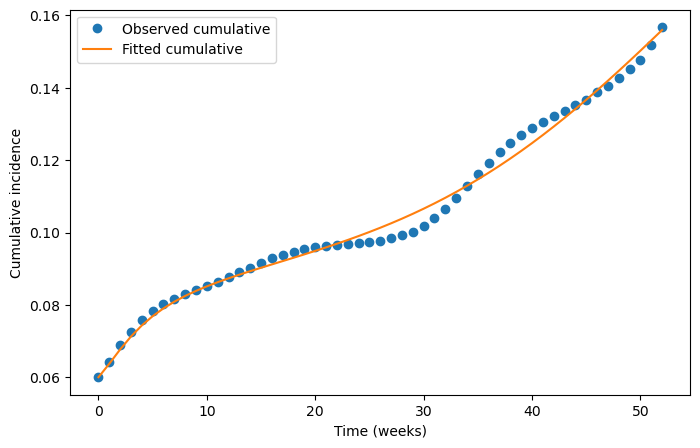

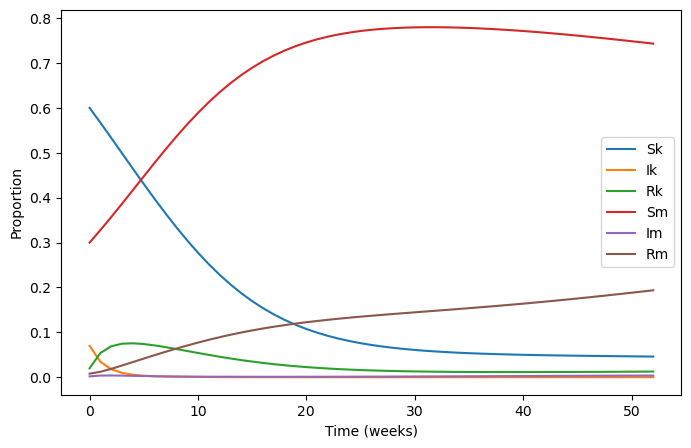

In [95]:
fitted_states = simulate_fixed_lambda(result_fixed_lambda.x, t_eval, y0)

Sk, Ik, Rk, Sm, Im, Rm, C_model = fitted_states

plt.figure(figsize=(8, 5))
plt.plot(t_eval, observed_cumulative, "o", label="Observed cumulative")
plt.plot(t_eval, C_model, "-", label="Fitted cumulative")
plt.xlabel("Time (weeks)")
plt.ylabel("Cumulative incidence")
plt.legend()
plt.grid(False)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(t_eval, Sk, label="Sk")
plt.plot(t_eval, Ik, label="Ik")
plt.plot(t_eval, Rk, label="Rk")
plt.plot(t_eval, Sm, label="Sm")
plt.plot(t_eval, Im, label="Im")
plt.plot(t_eval, Rm, label="Rm")
plt.xlabel("Time (weeks)")
plt.ylabel("Proportion")
plt.legend()
plt.grid(False)
plt.show()

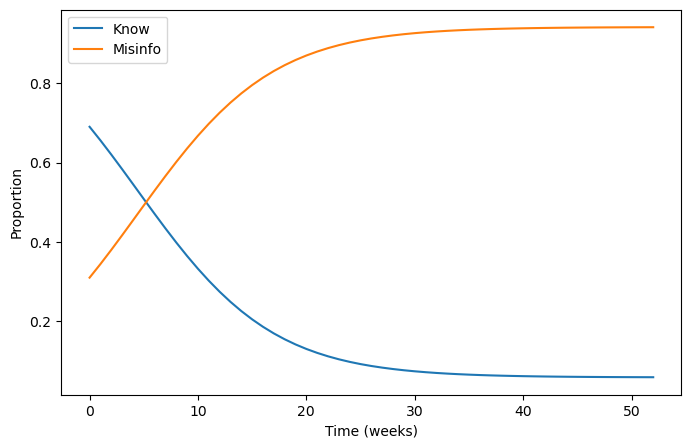

In [96]:
plt.figure(figsize=(8, 5))
plt.plot(t_eval, Sk + Ik + Rk, label="Know")
plt.plot(t_eval, Sm + Im + Rm, label="Misinfo")
plt.xlabel("Time (weeks)")
plt.ylabel("Proportion")
plt.legend()
plt.grid(False)
plt.show()